# **Model Prediction Risk Table**

This notebook creates a county-level prediction output table using the selected XGBoost baseline model.

The goal is to turn model predictions into an interpretable table that can later be used for a dashboard, map, or stakeholder report.

The table will include the county, IPC date, actual risk status, predicted risk status, predicted risk probability, and a simple risk level.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the master dataset
df = pd.read_csv("../02_data/processed/ipc_rainfall_ndvi_master_dataset.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (322, 19)


,ipc_date,analysis_period,county,max_ipc_phase,phase_3_plus_population,total_population,phase_3_plus_percentage,rainfall_date,mean_rainfall_mm,rainfall_3_month_total,rainfall_6_month_total,rainfall_3_month_avg,rainfall_6_month_avg,date,mean_ndvi,ndvi_1_month_mean,ndvi_3_month_mean,ndvi_6_month_mean,ndvi_anomaly
0,2019-07-01,Jul 2019,Baringo,4,105555,703697,0.15,2019-06-01,72.692665,143.441454,172.723779,47.813818,28.787296,2019-06-01,0.645498,0.645498,0.469621,0.424800,0.078739
1,2019-07-01,Jul 2019,Embu,3,32883,219220,0.15,2019-06-01,8.068131,123.946965,156.388124,41.315655,26.064687,2019-06-01,0.710059,0.710059,0.715939,0.708263,-0.026823
2,2019-07-01,Jul 2019,Garissa,4,151183,431950,0.35,2019-06-01,5.417682,55.185197,66.812339,18.395066,11.135390,2019-06-01,0.211246,0.211246,0.247841,0.247458,-0.047864
3,2019-07-01,Jul 2019,Isiolo,4,54413,155465,0.35,2019-06-01,0.936229,26.591658,40.062429,8.863886,6.677072,2019-06-01,0.207090,0.207090,0.223339,0.220767,-0.042075
4,2019-07-01,Jul 2019,Kajiado,3,43536,870721,0.05,2019-06-01,6.391582,62.716861,88.344720,20.905620,14.724120,2019-06-01,0.379489,0.379489,0.389526,0.366431,-0.030230


## **Load and Prepare Dataset**

The master dataset contains IPC food insecurity outcomes, CHIRPS rainfall indicators, and MODIS NDVI vegetation indicators.

This notebook uses the same dataset and feature columns as the baseline modeling notebook so that the risk table is consistent with the selected XGBoost model.

In [2]:
# Convert IPC date column to datetime
df["ipc_date"] = pd.to_datetime(df["ipc_date"])

# Create binary high-risk target
threshold = 0.20
df["high_risk"] = (df["phase_3_plus_percentage"] >= threshold).astype(int)

# Sort by IPC date for time-aware modeling
df = df.sort_values("ipc_date").reset_index(drop=True)

print("Dataset shape:", df.shape)
print("Date range:", df["ipc_date"].min(), "to", df["ipc_date"].max())
print("\nHigh-risk distribution:")
print(df["high_risk"].value_counts())
print("\nHigh-risk percentage:")
print(df["high_risk"].value_counts(normalize=True).mul(100).round(2))

Dataset shape: (322, 20)
Date range: 2019-07-01 00:00:00 to 2026-02-01 00:00:00

High-risk distribution:
high_risk
0    230
1     92
Name: count, dtype: int64

High-risk percentage:
high_risk
0    71.43
1    28.57
Name: proportion, dtype: float64


## **Prepare Modeling Target and Date Column**

The risk table uses the same target definition as the baseline modeling notebook.

A county-period is classified as high risk if **20% or more of the population is in IPC Phase 3 or worse**.

- `1` = High Risk
- `0` = Not High Risk

The `ipc_date` column is converted into datetime format and the dataset is sorted by date so that the train-test split follows time order.

## **Recreate Time-Aware Train-Test Split**

To keep this risk table consistent with the baseline modeling notebook, I recreate the same time-aware train-test split.

The model is trained on earlier records and tested on later records.

This allows the risk table to show predictions for the later test period, which is closer to a real early-warning use case.

In [4]:
# Define environmental feature columns
feature_cols = [
    "mean_rainfall_mm",
    "rainfall_3_month_total",
    "rainfall_6_month_total",
    "rainfall_3_month_avg",
    "rainfall_6_month_avg",
    "mean_ndvi",
    "ndvi_1_month_mean",
    "ndvi_3_month_mean",
    "ndvi_6_month_mean",
    "ndvi_anomaly"
]

# Use 80% of time-ordered records for training and 20% for testing
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

X_train = train_df[feature_cols]
y_train = train_df["high_risk"]

X_test = test_df[feature_cols]
y_test = test_df["high_risk"]

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))
print("Train date range:", train_df["ipc_date"].min(), "to", train_df["ipc_date"].max())
print("Test date range:", test_df["ipc_date"].min(), "to", test_df["ipc_date"].max())
print("Test high-risk cases:", y_test.sum())

Train rows: 257
Test rows: 65
Train date range: 2019-07-01 00:00:00 to 2025-02-01 00:00:00
Test date range: 2025-02-01 00:00:00 to 2026-02-01 00:00:00
Test high-risk cases: 16


## **Train Selected XGBoost Model**

The baseline modeling notebook selected XGBoost as the strongest balanced model.

In this notebook, I train the same XGBoost model again so that I can generate county-level risk predictions and probabilities for the test period.

In [5]:
from xgboost import XGBClassifier

# Calculate class imbalance weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Train selected XGBoost model
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
    min_child_weight=5,
    gamma=1
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully.")
print("scale_pos_weight:", round(scale_pos_weight, 2))

XGBoost model trained successfully.
scale_pos_weight: 2.38


### **Interpretation**

A value of `2.38` means the model gives the high-risk class more weight during training. This helps reduce the chance that the model ignores high-risk cases.

## **Create Prediction Risk Table**

After training the selected XGBoost model, I generate predictions for the test period.

The risk table includes:

- county
- IPC date
- actual high-risk status
- predicted high-risk status
- predicted risk probability
- simple risk level

This table is designed to be easier to use in a dashboard, map, or stakeholder report.

In [7]:
# Generate predictions for the test set
y_pred_xgb = xgb_model.predict(X_test)
y_pred_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Create prediction risk table
risk_table = test_df[[
    "ipc_date",
    "analysis_period",
    "county",
    "max_ipc_phase",
    "phase_3_plus_population",
    "total_population",
    "phase_3_plus_percentage"
]].copy()

risk_table["actual_high_risk"] = y_test.values
risk_table["predicted_high_risk"] = y_pred_xgb
risk_table["predicted_risk_probability"] = y_pred_prob_xgb

# Convert probability to percentage for easier reading
risk_table["predicted_risk_probability_pct"] = (
    risk_table["predicted_risk_probability"] * 100
).round(2)

# Preview the output
risk_table.head()

,ipc_date,analysis_period,county,max_ipc_phase,phase_3_plus_population,total_population,phase_3_plus_percentage,actual_high_risk,predicted_high_risk,predicted_risk_probability,predicted_risk_probability_pct
257,2025-02-01,Feb 2025,Tharaka Nithi,3,8900,178000,0.05,0,0,0.136688,13.670000
258,2025-02-01,Feb 2025,Tana River,3,52950,353000,0.15,0,1,0.585448,58.540001
259,2025-02-01,Feb 2025,Taita Taveta,3,18200,364000,0.05,0,0,0.245960,24.600000
260,2025-02-01,Feb 2025,Samburu,3,52200,348000,0.15,0,0,0.246713,24.670000
261,2025-02-01,Feb 2025,Nyeri,3,10250,205000,0.05,0,0,0.042494,4.250000


### **Interpretation**

The prediction risk table has been created successfully.

Each row represents a county-period in the test set and includes the actual risk status, the model's predicted risk status, and the predicted risk probability.

The `predicted_high_risk` column shows the model's classification:

- `1` = Predicted High Risk
- `0` = Predicted Not High Risk

The `predicted_risk_probability_pct` column shows how confident the model is that a county-period is high risk, expressed as a percentage.

This probability score is useful because it gives more detail than a simple 0 or 1 prediction. It can help rank counties by risk and support a dashboard or map.

## **Review Predicted Risk Probability Distribution**

Before assigning simple risk labels, I review the distribution of predicted risk probabilities across the test set.

This helps choose practical thresholds for the final risk categories.

The model gives each county-period a probability score between 0% and 100%. A higher percentage means the model sees a stronger chance that the county-period is high risk.

Reviewing the minimum, median, upper quartile, and maximum values helps decide how to group the predictions into low, moderate, and high risk levels.

In [8]:
# Check the distribution of probabilities across all test counties
risk_table["predicted_risk_probability_pct"].describe()

count    65.000000
mean     35.888924
std      32.205132
min       2.650000
25%      10.140000
50%      22.400000
75%      59.490002
max      95.900002
Name: predicted_risk_probability_pct, dtype: float64

### **Interpretation**

The predicted risk probabilities range from about 2.4% to 95.9%.

The average predicted risk is about 36.1%, while the median is about 22.5%. This means that many county-periods have relatively low predicted risk, but a smaller group has much higher predicted risk.

The 75th percentile is about 59.3%, meaning the top quarter of records are close to or above 60% predicted risk.

Based on this distribution, I use three simple dashboard-friendly risk labels:

- **Low Risk**: below 40%
- **Moderate Risk**: 40% to below 60%
- **High Risk**: 60% and above

The moderate-risk category is important because some true high-risk cases may fall just below the high-risk threshold. These records should still be monitored rather than ignored.

This approach keeps the output simple for interpretation while still preserving the model's probability score for ranking counties.

## **Add Risk Level Labels**

The predicted probability is useful, but a dashboard or stakeholder report needs a simpler label.

I convert the predicted probability into three risk levels:

- **Low Risk**: below 40%
- **Moderate Risk**: 40% to below 60%
- **High Risk**: 60% and above

The model prediction column still remains available, but the risk level makes the output easier to read and use.

In [9]:
# Create simple risk level labels from predicted probability
def assign_risk_level(probability):
    if probability >= 0.60:
        return "High Risk"
    elif probability >= 0.40:
        return "Moderate Risk"
    else:
        return "Low Risk"

risk_table["risk_level"] = risk_table["predicted_risk_probability"].apply(assign_risk_level)

# Sort by highest predicted risk probability
risk_table_sorted = risk_table.sort_values(
    "predicted_risk_probability",
    ascending=False
).reset_index(drop=True)

risk_table_sorted.head(15)

,ipc_date,analysis_period,county,max_ipc_phase,phase_3_plus_population,total_population,phase_3_plus_percentage,actual_high_risk,predicted_high_risk,predicted_risk_probability,predicted_risk_probability_pct,risk_level
0,2026-02-01,Feb 2026,Wajir,4,274500,915000,0.30,1,1,0.959004,95.900002,High Risk
1,2026-02-01,Feb 2026,Isiolo,3,66000,330000,0.20,1,1,0.956509,95.650002,High Risk
2,2026-02-01,Feb 2026,Mandera,4,503500,1007000,0.50,1,1,0.952531,95.250000,High Risk
3,2026-02-01,Feb 2026,Marsabit,4,134750,539000,0.25,1,1,0.949016,94.900002,High Risk
4,2025-02-01,Feb 2025,Marsabit,4,128750,515000,0.25,1,1,0.943127,94.309998,High Risk
5,2026-02-01,Feb 2026,Garissa,4,242750,971000,0.25,1,1,0.924551,92.459999,High Risk
6,2025-07-01,Jul 2025,Mandera,4,287700,959000,0.30,1,1,0.905623,90.559998,High Risk
7,2026-02-01,Feb 2026,Turkana,4,322200,1074000,0.30,1,1,0.904123,90.410004,High Risk
8,2025-02-01,Feb 2025,Isiolo,3,47400,316000,0.15,0,1,0.903001,90.300003,High Risk
9,2025-07-01,Jul 2025,Marsabit,3,103000,515000,0.20,1,1,0.857982,85.800003,High Risk


### **Interpretation**

The sorted risk table shows the county-periods with the highest predicted food insecurity risk.

Most of the top-ranked records are actual high-risk cases, which means the model is successfully pushing many true high-risk county-periods to the top of the table.

The highest-risk records are mainly ASAL counties such as Wajir, Mandera, Marsabit, Garissa, Turkana, Isiolo, and Tana River. These counties also appeared as important risk areas during the exploratory analysis.

The table also shows some false alarms, such as Isiolo in February 2025 and Wajir in July 2025. These records were not officially high risk based on the 20% Phase 3+ threshold, but the model still assigned high predicted risk. In an early-warning setting, these false alarms may still be useful for closer monitoring.

Overall, this table is more actionable than a raw model output because it ranks counties by predicted risk probability and adds a simple risk level label for dashboard or stakeholder use.

## **Risk Level Summary**

After assigning risk labels, I summarize how many county-periods fall into each risk category.

This helps show the overall risk distribution in the test period and gives a simple summary for dashboard reporting.

In [10]:
# Count records by risk level
risk_level_summary = risk_table["risk_level"].value_counts().reset_index()
risk_level_summary.columns = ["risk_level", "count"]

risk_level_summary

,risk_level,count
0,Low Risk,40
1,High Risk,15
2,Moderate Risk,10


### **Interpretation**

The risk level summary shows that most county-periods in the test set are classified as Low Risk.

Out of 65 test records, 40 are classified as Low Risk, 10 as Moderate Risk, and 15 as High Risk.

This means the model is not flagging every county-period as dangerous. Instead, it separates the test records into a smaller group that requires closer attention.

The 15 High Risk records should be prioritized for review, while the 10 Moderate Risk records should be monitored because some may be close to the high-risk threshold.

This summary is useful for dashboard reporting because it gives a quick overview of how many county-periods fall into each risk category.

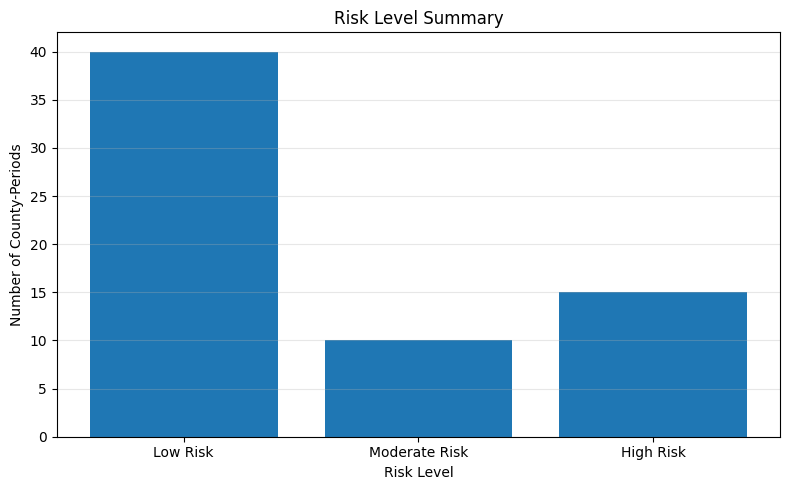

In [12]:
# Order risk levels for clearer visualization
risk_order = ["Low Risk", "Moderate Risk", "High Risk"]

risk_level_summary_ordered = risk_level_summary.set_index("risk_level").loc[risk_order].reset_index()

# Visualize risk level summary
plt.figure(figsize=(8, 5))

plt.bar(
    risk_level_summary_ordered["risk_level"],
    risk_level_summary_ordered["count"]
)

plt.title("Risk Level Summary")
plt.xlabel("Risk Level")
plt.ylabel("Number of County-Periods")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### **Interpretation**

The risk level chart shows that most county-periods in the test set are classified as Low Risk.

However, the model also identifies a smaller group of Moderate Risk and High Risk records that should receive closer attention.

The High Risk group should be prioritized first, while the Moderate Risk group should be monitored because some records may be close to the high-risk threshold.


## **Save Prediction Risk Table**

The final step is to save the prediction risk table as a CSV file.

This output can be used later for a dashboard, map, or stakeholder-facing report.

In [13]:
# Save sorted risk table to processed data folder
output_path = "../02_data/processed/model_prediction_risk_table.csv"

risk_table_sorted.to_csv(output_path, index=False)

print("Risk table saved to:", output_path)
print("Output shape:", risk_table_sorted.shape)

Risk table saved to: ../02_data/processed/model_prediction_risk_table.csv
Output shape: (65, 12)


### **Interpretation**

The prediction risk table was successfully saved as a CSV file.

The final output contains 65 rows and 12 columns. Each row represents a county-period from the test set and includes the actual risk status, predicted risk status, predicted risk probability, and dashboard-friendly risk level.

This file can now be used as an input for the next stage of the project, such as a county-level risk dashboard, map, or stakeholder report.

## **Conclusion**

This notebook created a county-level prediction risk table using the selected XGBoost baseline model.

The model was trained using the same rainfall and NDVI features from the baseline modeling notebook. Predictions were generated for the test period and converted into an interpretable output table.

The final risk table includes:

- county
- IPC date
- actual high-risk status
- predicted high-risk status
- predicted risk probability
- predicted risk probability percentage
- risk level

The risk levels classify county-periods as Low Risk, Moderate Risk, or High Risk based on the predicted probability.

This output is useful because it turns model results into a format that can support a dashboard, map, or stakeholder-facing early-warning report.

The next stage of the project is to use this saved CSV file to build a county-level risk dashboard or map.